In [2]:
from google.colab import files
uploaded = files.upload()

Saving E-Commerce details - Extract 1.csv to E-Commerce details - Extract 1.csv


In [3]:
import pandas as pd
df = pd.read_csv('E-Commerce details - Extract 1.csv')
df.head()


,transaction_id,order_date,customer_id,product_id,product_name,category,subcategory,brand,original_price_inr,discount_percent,...,customer_rating,return_status,order_month,order_year,order_quarter,product_weight_kg,is_prime_eligible,product_rating,price_outlier_IQR,price_outlier_3sigma
0,TXN_2023_00061476,7/21/2023,CUST_2023_00001386,PROD_000001,Apple iPhone 6 16GB Black,electronics,Smartphones,Apple,182837.02,0.00,...,4.500000,Delivered,7,2023,3,0.21,True,3.9,False,False
1,TXN_2021_00098748,10/3/2021,CUST_2021_00012569,PROD_000002,Apple iPhone 6 32GB Black,electronics,Smartphones,Apple,206713.04,47.67,...,4.000000,Delivered,10,2021,4,0.18,True,3.4,False,False
2,TXN_2022_00054823,6/14/2022,CUST_2021_00013094,PROD_000002,Apple iPhone 6 32GB Black,electronics,Smartphones,Apple,163426.13,0.00,...,4.340115,Delivered,6,2022,2,0.18,True,3.4,False,False
3,TXN_2021_00020451,2/26/2021,CUST_2021_00008413,PROD_000003,Apple iPhone 6 64GB Black,electronics,Smartphones,Apple,154150.77,0.00,...,4.500000,Delivered,2,2021,1,0.22,True,4.6,False,False
4,TXN_2024_00048353,6/22/2024,CUST_2022_00042941,PROD_000003,Apple iPhone 6 64GB Black,electronics,Smartphones,Apple,102829.98,24.40,...,4.000000,Delivered,6,2024,2,0.22,True,4.6,False,False


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 36 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   transaction_id          50000 non-null  object 
 1   order_date              50000 non-null  object 
 2   customer_id             50000 non-null  object 
 3   product_id              50000 non-null  object 
 4   product_name            50000 non-null  object 
 5   category                50000 non-null  object 
 6   subcategory             50000 non-null  object 
 7   brand                   50000 non-null  object 
 8   original_price_inr      50000 non-null  float64
 9   discount_percent        50000 non-null  float64
 10  discounted_price_inr    50000 non-null  float64
 11  quantity                50000 non-null  int64  
 12  subtotal_inr            50000 non-null  float64
 13  delivery_charges        50000 non-null  int64  
 14  final_amount_inr        50000 non-null

In [5]:
south_states = ['Tamil Nadu', 'Kerala', 'Karnataka', 'Andhra Pradesh', 'Telangana']
df_south = df[df['customer_state'].isin(south_states)]

df_south.to_csv('south_india_ecommerce.csv', index=False)

from google.colab import files
files.download('south_india_ecommerce.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [6]:
import pandas as pd
df = pd.read_csv('south_india_ecommerce.csv')
df.head()

,transaction_id,order_date,customer_id,product_id,product_name,category,subcategory,brand,original_price_inr,discount_percent,...,customer_rating,return_status,order_month,order_year,order_quarter,product_weight_kg,is_prime_eligible,product_rating,price_outlier_IQR,price_outlier_3sigma
0,TXN_2022_00054823,6/14/2022,CUST_2021_00013094,PROD_000002,Apple iPhone 6 32GB Black,electronics,Smartphones,Apple,163426.13,0.00,...,4.340115,Delivered,6,2022,2,0.18,True,3.4,False,False
1,TXN_2022_00112586,11/13/2022,CUST_2022_00017473,PROD_000003,Apple iPhone 6 64GB Black,electronics,Smartphones,Apple,121870.70,0.00,...,4.340115,Delivered,11,2022,4,0.22,True,4.6,False,False
2,TXN_2022_00033829,4/25/2022,CUST_2022_00031791,PROD_000003,Apple iPhone 6 64GB Black,electronics,Smartphones,Apple,46625.88,0.00,...,4.340115,Delivered,4,2022,2,0.22,True,4.6,False,False
3,TXN_2023_00028581,3/31/2023,CUST_2023_00029802,PROD_000005,Apple iPhone 6 32GB White,electronics,Smartphones,Apple,110205.96,8.21,...,4.340115,Delivered,3,2023,1,0.20,True,3.8,False,False
4,TXN_2022_00086875,9/17/2022,CUST_2022_00047258,PROD_000005,Apple iPhone 6 32GB White,electronics,Smartphones,Apple,118430.51,0.00,...,4.000000,Delivered,9,2022,3,0.20,True,3.8,False,False


We got our dataset for our analysis, let's go for data wrangling:


In [7]:
# Data info
df_south.info()

# Missing values
print("\nMissing values:\n", df_south.isnull().sum())

# Duplicate rows
print("\nDuplicate rows:", df_south.duplicated().sum())
print("Duplicate transaction_ids:", df_south['transaction_id'].duplicated().sum())

# Quick stats on key numeric columns
df_south[['final_amount_inr', 'quantity', 'discount_percent']].describe()

<class 'pandas.core.frame.DataFrame'>
Index: 12714 entries, 2 to 49998
Data columns (total 36 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   transaction_id          12714 non-null  object 
 1   order_date              12714 non-null  object 
 2   customer_id             12714 non-null  object 
 3   product_id              12714 non-null  object 
 4   product_name            12714 non-null  object 
 5   category                12714 non-null  object 
 6   subcategory             12714 non-null  object 
 7   brand                   12714 non-null  object 
 8   original_price_inr      12714 non-null  float64
 9   discount_percent        12714 non-null  float64
 10  discounted_price_inr    12714 non-null  float64
 11  quantity                12714 non-null  int64  
 12  subtotal_inr            12714 non-null  float64
 13  delivery_charges        12714 non-null  int64  
 14  final_amount_inr        12714 non-null  flo

,final_amount_inr,quantity,discount_percent
count,1.271400e+04,12714.000000,12714.000000
mean,7.688971e+04,1.247286,17.515565
std,7.754611e+04,0.528770,20.665358
min,1.032640e+03,1.000000,0.000000
25%,2.767131e+04,1.000000,0.000000
50%,5.234676e+04,1.000000,10.275000
75%,9.993556e+04,1.000000,28.550000
max,1.024425e+06,3.000000,69.980000


Let's focus on: subcategory (Smartphones, Laptops, etc.), brand, state, season, and festival as our analysis dimensions.
Our story is: "How do festivals and seasons drive electronics purchases across South Indian states"

In [8]:
print("Date range:", df_south['order_date'].min(), "to", df_south['order_date'].max())
print("\nCategories:\n", df_south['category'].value_counts())
print("\nState-wise rows:\n", df_south['customer_state'].value_counts())

Date range: 1/1/2021 to 9/9/2025

Categories:
 category
electronics    12714
Name: count, dtype: int64

State-wise rows:
 customer_state
Tamil Nadu        4558
Karnataka         4156
Telangana         1813
Kerala            1128
Andhra Pradesh    1059
Name: count, dtype: int64


In [9]:
print("Subcategories:\n", df_south['subcategory'].value_counts())
print("\nFestival breakdown:\n", df_south['festival_name'].value_counts())
print("\nIs festival sale:\n", df_south['is_festival_sale'].value_counts())

Subcategories:
 subcategory
Smartphones           9597
Laptops                985
Smart Watch            778
Tablets                706
Audio                  442
TV & Entertainment     206
Name: count, dtype: int64

Festival breakdown:
 festival_name
No Festival                     8771
Back to School                   973
Diwali Sale                      929
Amazon Great Indian Festival     546
Summer Sale                      494
Holi Festival                    475
Republic Day Sale                236
Valentine Sale                   188
Prime Day                        102
Name: count, dtype: int64

Is festival sale:
 is_festival_sale
False    8771
True     3943
Name: count, dtype: int64


Now let's replace those 8,771 "No Festival" rows with actual regional festivals like Pongal, Onam, Ugadi, Vishu, Ramzan, Christmas, etc. based on the date.

In [10]:
import pandas as pd
from datetime import timedelta

# Exact dates per year (multi-day festivals stored as start,end / single-day stored as just the date)
festival_dates = {
    'Pongal': {
        2021: ('2021-01-14','2021-01-17'), 2022: ('2022-01-14','2022-01-17'),
        2023: ('2023-01-15','2023-01-18'), 2024: ('2024-01-15','2024-01-18'),
        2025: ('2025-01-13','2025-01-16'),
    },
    'Ugadi': {
        2021: '2021-04-13', 2022: '2022-04-02', 2023: '2023-03-22',
        2024: '2024-04-09', 2025: '2025-03-30',
    },
    'Onam': {
        2021: '2021-08-21', 2022: '2022-09-08', 2023: '2023-08-29',
        2024: '2024-09-15', 2025: '2025-09-05',
    },
    'Ramadan': {
        2021: ('2021-04-13','2021-05-12'), 2022: ('2022-04-02','2022-05-01'),
        2023: ('2023-03-23','2023-04-20'), 2024: ('2024-03-11','2024-04-09'),
        2025: ('2025-03-01','2025-03-29'),
    },
    'Christmas': {y: f'{y}-12-25' for y in range(2021,2026)},
    'Vishu_Puthandu': {y: f'{y}-04-14' for y in range(2021,2026)},
    'Diwali': {
        2021: '2021-11-04', 2022: '2022-10-24', 2023: '2023-11-12',
        2024: '2024-11-01', 2025: '2025-10-20',
    },
    'Navratri_Dussehra': {
        2021: '2021-10-15', 2022: '2022-10-05', 2023: '2023-10-24',
        2024: '2024-10-12', 2025: '2025-10-02',
    },
    'Ganesh_Chaturthi': {
        2021: '2021-09-10', 2022: '2022-08-31', 2023: '2023-09-19',
        2024: '2024-09-07', 2025: '2025-08-27',
    },
}

# Build (start,end) windows: 20 days before start through the end date
festival_windows = {}
for fest, years in festival_dates.items():
    festival_windows[fest] = {}
    for yr, val in years.items():
        if isinstance(val, tuple):
            start, end = pd.Timestamp(val[0]), pd.Timestamp(val[1])
        else:
            start = end = pd.Timestamp(val)
        festival_windows[fest][yr] = (start - timedelta(days=20), end)

def get_cultural_festivals(date):
    matches = []
    for fest, years in festival_windows.items():
        yr = date.year
        if yr in years:
            start, end = years[yr]
            if start <= date <= end:
                matches.append(fest.replace('_', ' '))
    return matches

In [11]:
# Add remaining festivals with assumed representative dates (same month each year)
for y in range(2021, 2026):
    festival_dates.setdefault('Thrissur_Pooram', {})[y] = f'{y}-04-20'      # April-May -> mid/late April
    festival_dates.setdefault('Varalakshmi_Vratam', {})[y] = f'{y}-08-16'   # July-August -> mid August
    festival_dates.setdefault('Karthigai_Deepam', {})[y] = f'{y}-12-05'     # Nov-Dec -> early December
    festival_dates.setdefault('Vaikunta_Ekadasi', {})[y] = f'{y}-01-01'     # Dec-Jan -> early January

# Rebuild festival_windows to include the new entries
festival_windows = {}
for fest, years in festival_dates.items():
    festival_windows[fest] = {}
    for yr, val in years.items():
        if isinstance(val, tuple):
            start, end = pd.Timestamp(val[0]), pd.Timestamp(val[1])
        else:
            start = end = pd.Timestamp(val)
        festival_windows[fest][yr] = (start - timedelta(days=20), end)

def get_cultural_festivals(date):
    matches = []
    for fest, years in festival_windows.items():
        yr = date.year
        if yr in years:
            start, end = years[yr]
            if start <= date <= end:
                matches.append(fest.replace('_', ' '))
    return matches

# Make sure order_date is datetime
df_south['order_date'] = pd.to_datetime(df_south['order_date'])

# Apply and append to existing festival_name
def combine_festival(row):
    cultural = get_cultural_festivals(row['order_date'])
    existing = row['festival_name']
    if existing == 'No Festival':
        return ' + '.join(cultural) if cultural else 'No Festival'
    else:
        new_ones = [f for f in cultural if f.lower() not in existing.lower()]
        return existing + (' + ' + ' + '.join(new_ones) if new_ones else '')

df_south['festival_name_updated'] = df_south.apply(combine_festival, axis=1)

df_south['festival_name_updated'].value_counts()

,count
festival_name_updated,
No Festival,3108
Christmas,1010
Back to School,973
Diwali Sale,827
Karthigai Deepam,815
Pongal,540
Summer Sale,404
Varalakshmi Vratam,398
Ganesh Chaturthi,385


Will get the cleaned csv file


In [12]:
columns_to_keep = [
    'transaction_id', 'order_date', 'customer_state', 'customer_city',
    'category', 'subcategory', 'brand',
    'final_amount_inr', 'quantity', 'discount_percent',
    'payment_method', 'is_prime_member',
    'festival_name_updated',
    'order_month', 'order_year', 'order_quarter',
    'customer_rating', 'return_status'
]

df_clean = df_south[columns_to_keep]
df_clean = df_clean.rename(columns={'festival_name_updated': 'festival_name'})  # clean name for final file

df_clean.to_csv('south_india_festival_cleaned.csv', index=False)

from google.colab import files
files.download('south_india_festival_cleaned.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Now our file is ready for Analysis. Let's start:

In [13]:
# 1. Sales by festival
festival_sales = df_clean.groupby('festival_name')['final_amount_inr'].agg(['sum','mean','count']).sort_values('sum', ascending=False)
print(festival_sales)

# 2. Festival sales by state (top 20)
festival_state = df_clean.groupby(['customer_state','festival_name'])['final_amount_inr'].sum().reset_index()
print(festival_state.sort_values('final_amount_inr', ascending=False).head(20))

# 3. Monthly/seasonal pattern
monthly_sales = df_clean.groupby('order_month')['final_amount_inr'].sum()
print(monthly_sales)

# 4. Subcategory performance: festival vs non-festival
df_clean['is_festival'] = df_clean['festival_name'] != 'No Festival'
subcat_festival = df_clean.groupby(['subcategory','is_festival'])['final_amount_inr'].mean().unstack()
print(subcat_festival)

                                                             sum  \
festival_name                                                      
No Festival                                         2.733107e+08   
Christmas                                           8.609197e+07   
Karthigai Deepam                                    6.900571e+07   
Back to School                                      5.085624e+07   
Pongal                                              4.919816e+07   
Diwali Sale                                         4.433432e+07   
Ganesh Chaturthi                                    3.735498e+07   
Varalakshmi Vratam                                  3.276248e+07   
Ramadan                                             2.760643e+07   
Navratri Dussehra                                   2.652495e+07   
Onam                                                2.156634e+07   
Summer Sale                                         2.047341e+07   
Amazon Great Indian Festival + Navratri Dussehra

/tmp/ipykernel_6472/2765980260.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=festival_sales_sorted.values, y=festival_sales_sorted.index, palette='viridis')


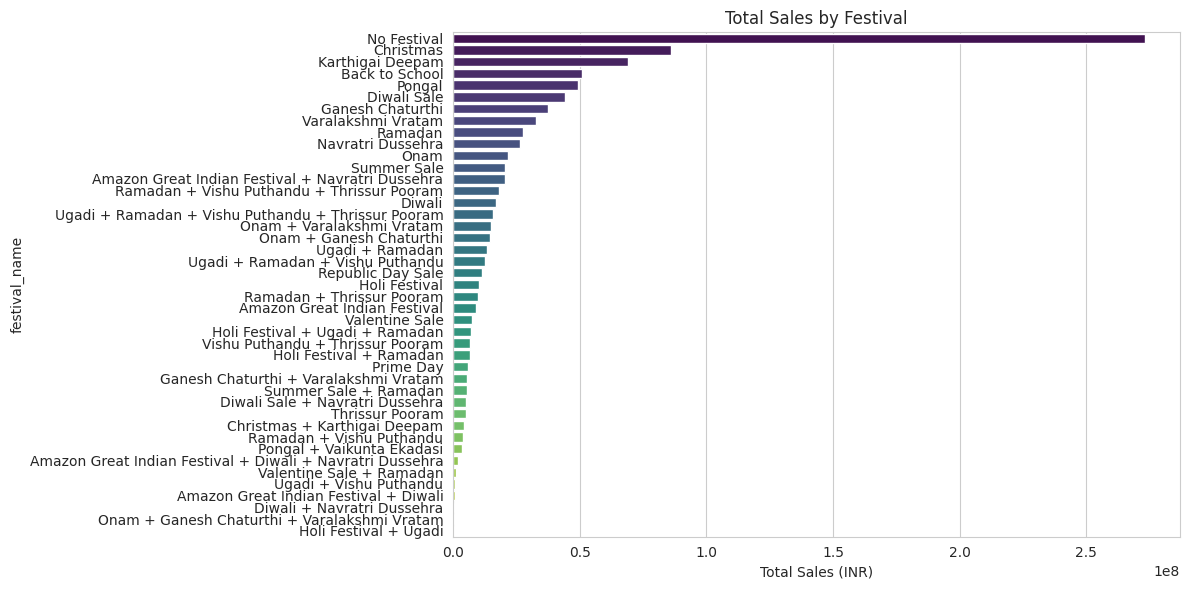

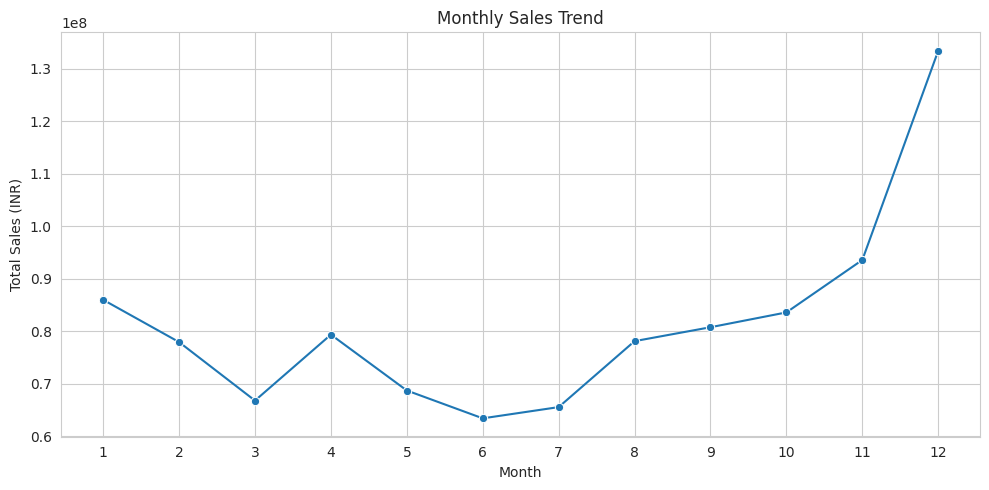

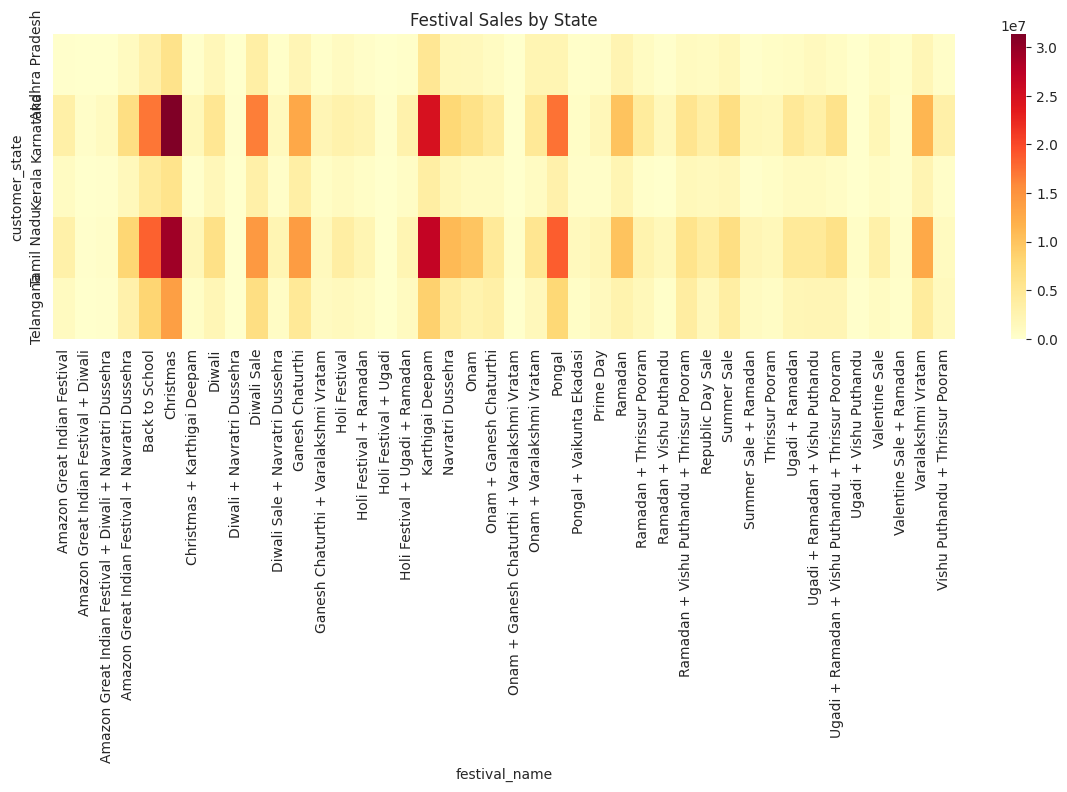

<Figure size 1000x600 with 0 Axes>

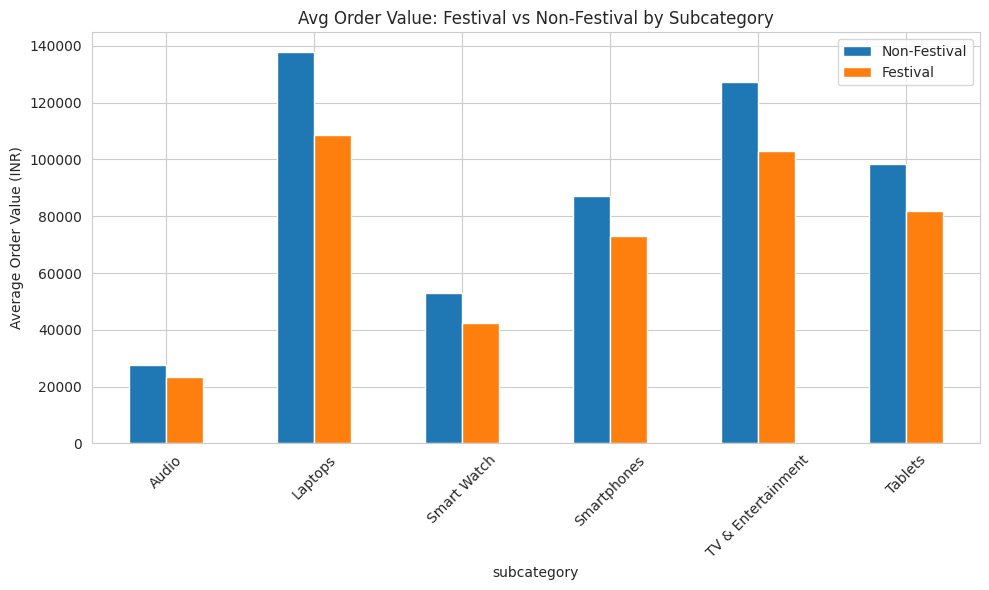

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('whitegrid')

# 1. Sales by festival (bar chart)
plt.figure(figsize=(12,6))
festival_sales_sorted = df_clean.groupby('festival_name')['final_amount_inr'].sum().sort_values(ascending=False)
sns.barplot(x=festival_sales_sorted.values, y=festival_sales_sorted.index, palette='viridis')
plt.title('Total Sales by Festival')
plt.xlabel('Total Sales (INR)')
plt.tight_layout()
plt.show()

# 2. Monthly seasonal trend (line chart)
plt.figure(figsize=(10,5))
monthly_sales = df_clean.groupby('order_month')['final_amount_inr'].sum()
sns.lineplot(x=monthly_sales.index, y=monthly_sales.values, marker='o')
plt.title('Monthly Sales Trend')
plt.xlabel('Month')
plt.ylabel('Total Sales (INR)')
plt.xticks(range(1,13))
plt.tight_layout()
plt.show()

# 3. Festival sales by state (heatmap)
plt.figure(figsize=(12,8))
pivot = df_clean[df_clean['festival_name']!='No Festival'].pivot_table(
    index='customer_state', columns='festival_name', values='final_amount_inr', aggfunc='sum', fill_value=0
)
sns.heatmap(pivot, cmap='YlOrRd', annot=False)
plt.title('Festival Sales by State')
plt.tight_layout()
plt.show()

# 4. Subcategory: festival vs non-festival avg order value
plt.figure(figsize=(10,6))
df_clean['is_festival'] = df_clean['festival_name'] != 'No Festival'
subcat_avg = df_clean.groupby(['subcategory','is_festival'])['final_amount_inr'].mean().unstack()
subcat_avg.plot(kind='bar', figsize=(10,6))
plt.title('Avg Order Value: Festival vs Non-Festival by Subcategory')
plt.ylabel('Average Order Value (INR)')
plt.xticks(rotation=45)
plt.legend(['Non-Festival','Festival'])
plt.tight_layout()
plt.show()

**A** **bar** **chart** :  Indicates "No Festival" time have more sales compare to individual festivals and Festivals like "Karthigai Deepam and Ramadan" have more sales.

**A** **line** **chart** : Shows monthly seasonal pattern where sales is more at the last month it can be due to "christmas festival" , "winter season" sale can be "New Year" sale.

**Heatmap** : Indicates which states peak during which festivals That is here it shows Tamil Nadu and Karnataka have more sales.

**Comparision** **chart** : Shows average order value during festivals vs regular days by subcategory.


In [15]:
# 1. Festival performance - sales per day of festival duration (fairer comparison)
festival_days = {
    'No Festival': 250,  # approx regular days in a year
    'Karthigai Deepam': 20, 'Ramadan': 40, 'Diwali': 21, 'Pongal': 24,
    'Onam': 21, 'Ugadi': 21, 'Christmas': 21, 'Navratri Dussehra': 21,
    'Ganesh Chaturthi': 21, 'Vishu Puthandu': 21
}  # adjust based on your actual windows (20 days pre + duration)

festival_sales = df_clean.groupby('festival_name')['final_amount_inr'].agg(['sum','mean','count'])
festival_sales['total_pct'] = (festival_sales['sum'] / festival_sales['sum'].sum() * 100).round(2)
print(festival_sales.sort_values('sum', ascending=False))

# 2. Monthly % difference from average
monthly_sales = df_clean.groupby('order_month')['final_amount_inr'].sum()
avg_monthly = monthly_sales.mean()
monthly_pct_diff = ((monthly_sales - avg_monthly) / avg_monthly * 100).round(1)
print("\nMonthly % difference from average:\n", monthly_pct_diff.sort_values(ascending=False))

# 3. State share of total sales (to contextualize heatmap)
state_share = df_clean.groupby('customer_state')['final_amount_inr'].sum()
state_share_pct = (state_share / state_share.sum() * 100).round(2)
print("\nState share of total sales:\n", state_share_pct.sort_values(ascending=False))

# 4. Subcategory festival lift (% increase during festivals)
subcat_avg = df_clean.groupby(['subcategory','is_festival'])['final_amount_inr'].mean().unstack()
subcat_avg['pct_lift'] = ((subcat_avg[True] - subcat_avg[False]) / subcat_avg[False] * 100).round(1)
print("\nSubcategory festival lift %:\n", subcat_avg.sort_values('pct_lift', ascending=False))

                                                             sum  \
festival_name                                                      
No Festival                                         2.733107e+08   
Christmas                                           8.609197e+07   
Karthigai Deepam                                    6.900571e+07   
Back to School                                      5.085624e+07   
Pongal                                              4.919816e+07   
Diwali Sale                                         4.433432e+07   
Ganesh Chaturthi                                    3.735498e+07   
Varalakshmi Vratam                                  3.276248e+07   
Ramadan                                             2.760643e+07   
Navratri Dussehra                                   2.652495e+07   
Onam                                                2.156634e+07   
Summer Sale                                         2.047341e+07   
Amazon Great Indian Festival + Navratri Dussehra

Here are your results organized into clean tables:

**Top Festivals by Sales Share (clean, single-festival rows)**

| Festival | Total Sales (₹) | Avg Order (₹) | Orders | % of Total |
|---|---|---|---|---|
| No Festival | 27.33 Cr | 87,938 | 3,108 | 27.96% |
| Christmas | 8.61 Cr | 85,240 | 1,010 | 8.81% |
| Karthigai Deepam | 6.90 Cr | 84,670 | 815 | 7.06% |
| Back to School | 5.09 Cr | 52,267 | 973 | 5.20% |
| Pongal | 4.92 Cr | 91,108 | 540 | 5.03% |
| Diwali Sale | 4.43 Cr | 53,609 | 827 | 4.54% |
| Ganesh Chaturthi | 3.74 Cr | 97,026 | 385 | 3.82% |
| Varalakshmi Vratam | 3.28 Cr | 82,318 | 398 | 3.35% |
| Ramadan | 2.76 Cr | 83,152 | 332 | 2.82% |
| Navratri Dussehra | 2.65 Cr | 98,241 | 270 | 2.71% |
| Onam | 2.16 Cr | 87,313 | 247 | 2.21% |

**Monthly Sales vs Yearly Average**

| Month | % Difference |
|---|---|
| December | +63.8% |
| November | +14.9% |
| January | +5.6% |
| October | +2.6% |
| September | -0.8% |
| April | -2.6% |
| August | -4.1% |
| February | -4.3% |
| May | -15.6% |
| March | -18.0% |
| July | -19.5% |
| June | -22.1% |

**State Share of Total Sales**

| State | % of Total Sales |
|---|---|
| Tamil Nadu | 35.86% |
| Karnataka | 34.89% |
| Telangana | 14.86% |
| Kerala | 7.27% |
| Andhra Pradesh | 7.12% |

**Subcategory Festival Lift (Avg Order Value)**

| Subcategory | Non-Festival (₹) | Festival (₹) | % Lift |
|---|---|---|---|
| Audio | 27,488 | 23,303 | -15.2% |
| Smartphones | 87,057 | 73,154 | -16.0% |
| Tablets | 98,396 | 81,990 | -16.7% |
| TV & Entertainment | 127,285 | 102,971 | -19.1% |
| Smart Watch | 52,984 | 42,249 | -20.3% |
| Laptops | 137,852 | 108,760 | -21.1% |


/tmp/ipykernel_6472/2536020036.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=monthly_pct_diff_sorted.index, y=monthly_pct_diff_sorted.values, palette=colors)


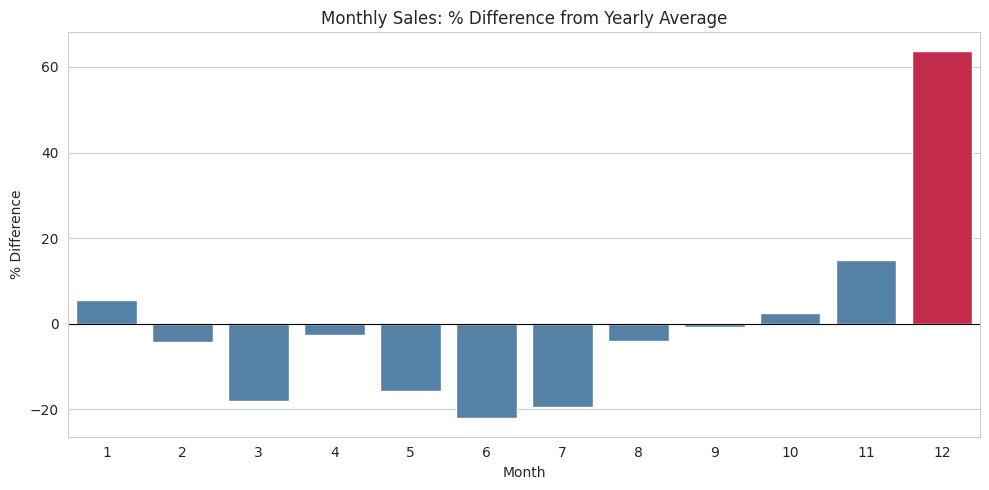

/tmp/ipykernel_6472/2536020036.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_festivals['total_pct'], y=top_festivals.index, palette='rocket')


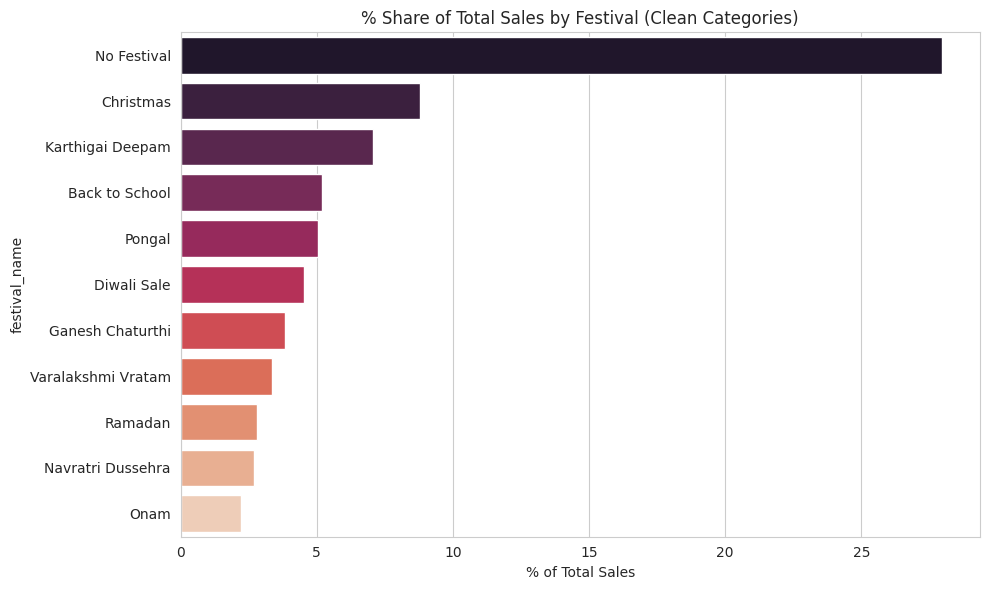

/tmp/ipykernel_6472/2536020036.py:34: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=subcat_lift_sorted.values, y=subcat_lift_sorted.index, palette=colors2)


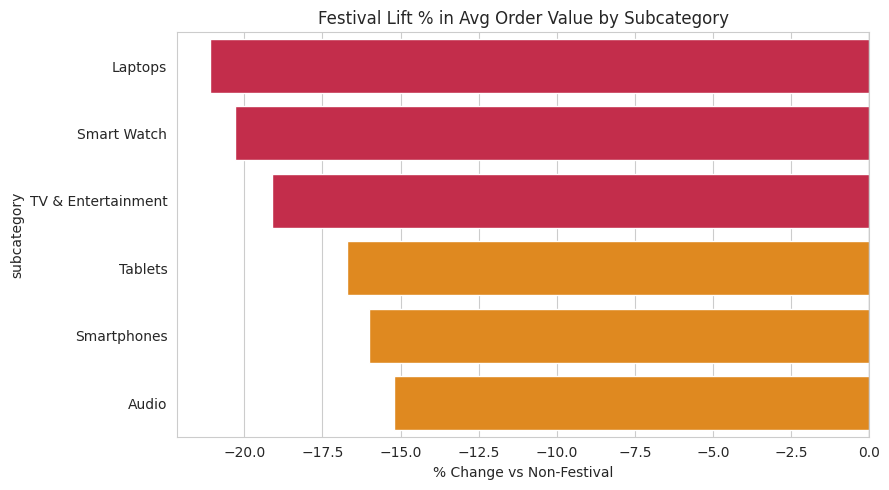

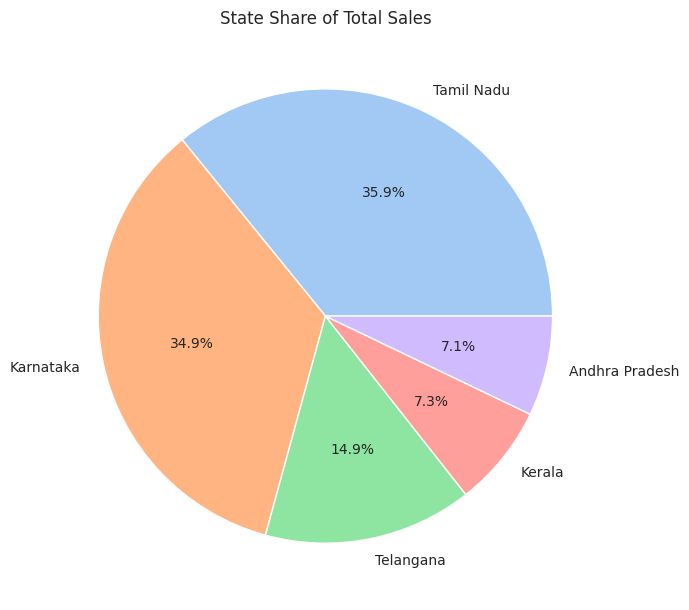

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('whitegrid')

# 1. Monthly % difference from average (highlight Dec/Nov)
plt.figure(figsize=(10,5))
monthly_pct_diff_sorted = monthly_pct_diff.sort_index()
colors = ['crimson' if v > 20 else 'steelblue' for v in monthly_pct_diff_sorted.values]
sns.barplot(x=monthly_pct_diff_sorted.index, y=monthly_pct_diff_sorted.values, palette=colors)
plt.title('Monthly Sales: % Difference from Yearly Average')
plt.xlabel('Month')
plt.ylabel('% Difference')
plt.axhline(0, color='black', linewidth=0.8)
plt.tight_layout()
plt.show()

# 2. Top 8 single festivals by % share of total sales (excluding messy combos)
clean_festivals = ['No Festival','Christmas','Karthigai Deepam','Back to School','Pongal',
                    'Diwali Sale','Ganesh Chaturthi','Varalakshmi Vratam','Ramadan',
                    'Navratri Dussehra','Onam']
top_festivals = festival_sales.loc[festival_sales.index.isin(clean_festivals)].sort_values('total_pct', ascending=False)
plt.figure(figsize=(10,6))
sns.barplot(x=top_festivals['total_pct'], y=top_festivals.index, palette='rocket')
plt.title('% Share of Total Sales by Festival (Clean Categories)')
plt.xlabel('% of Total Sales')
plt.tight_layout()
plt.show()

# 3. Subcategory festival lift % (all negative - the surprise finding)
plt.figure(figsize=(9,5))
subcat_lift_sorted = subcat_avg['pct_lift'].sort_values()
colors2 = ['crimson' if v < -19 else 'darkorange' for v in subcat_lift_sorted.values]
sns.barplot(x=subcat_lift_sorted.values, y=subcat_lift_sorted.index, palette=colors2)
plt.title('Festival Lift % in Avg Order Value by Subcategory')
plt.xlabel('% Change vs Non-Festival')
plt.axvline(0, color='black', linewidth=0.8)
plt.tight_layout()
plt.show()

# 4. State share of total sales (pie chart)
plt.figure(figsize=(7,7))
state_share_pct_sorted = state_share_pct.sort_values(ascending=False)
plt.pie(state_share_pct_sorted.values, labels=state_share_pct_sorted.index, autopct='%1.1f%%',
        colors=sns.color_palette('pastel'))
plt.title('State Share of Total Sales')
plt.tight_layout()
plt.show()

Key Findings:
- December sales are 63.8% above yearly average, driven by Christmas + Karthigai Deepam overlap
- Festival periods show LOWER average order value across all subcategories (-15% to -21%),
  suggesting festivals drive volume/discount-seeking rather than higher-ticket purchases
- Tamil Nadu and Karnataka account for ~71% of total sales, roughly proportional to their
  share of total orders in the dataset

In [17]:
# Export the enhanced festival-tagged dataset for dashboarding
df_clean.to_csv('south_india_dashboard_ready.csv', index=False)

from google.colab import files
files.download('south_india_dashboard_ready.csv')


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## Business Recommendations

**1. Prioritize December-January Inventory & Marketing Spend**
December sales are 63.8% above the yearly average (driven by Christmas + Karthigai Deepam overlap),
with November also elevated (+14.9%). Retailers should front-load electronics inventory
(especially Smartphones, the top-selling subcategory) by early November and increase ad spend
in this window rather than spreading budget evenly across the year.

**2. Rethink the "More Discount = More Revenue" Assumption**
Average order value drops 15-21% across every subcategory during festival periods, despite festivals
driving higher order volume. This suggests festival discounting attracts price-sensitive buyers
toward lower-ticket items rather than lifting overall basket value. Recommendation: pair festival
discounts with bundling or upsell prompts (e.g., accessories with phones) to protect average order
value during high-traffic sale periods.

**3. Treat Karthigai Deepam and Pongal as Standalone Regional Campaigns**
Despite short durations, Karthigai Deepam (7.06% of total sales) and Pongal (5.03%) punch above
their weight relative to single-day/short festivals like Republic Day or Valentine's sales.
These deserve dedicated regional marketing campaigns rather than being folded into generic
"festival sale" banners.


**4. Validate Regional Findings with a Larger, Balanced Sample**
Tamil Nadu (35.86%) and Karnataka (34.89%) dominate total sales, but this closely mirrors their
share of total orders in the dataset — suggesting the pattern may reflect data volume rather than
genuine higher regional demand. Recommend expanding the dataset with more balanced state
representation before making firm regional investment decisions.